In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF


N = 10000
K = 5
W = 0.6
iterations = 5
MIN_S = 0.3
MAX_S = 0.95


cols = ['condition', 't', 't_est', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score', 'true_score', 'algorithm','iteration']

scores = pd.DataFrame(columns=cols)

for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition(min_s=MIN_S, max_s=MAX_S)

    ct_D = CT(data, on = "D")
    ct_D.fit(max_depth=6)
    ct_D.parse_tree()

    ct_P = CT(data, on = "P")
    ct_P.fit(max_depth=6)
    ct_P.parse_tree()

    cf_mse = CF(data)
    cf_mse.fit(criterion="mse", n_estimators=100, max_depth=4)
    cf_mse.parse_forest()  


    for alg in [ct_D, ct_P, cf_mse]:
        score = alg.get_topK(k=K, w=W, print_summaries=False)
        score['iteration'] = exp
        score['p'] = data.p
        scores=pd.concat([scores, score], ignore_index=True)

    cf_mse.single_tree_interpreter(max_depth=10)

    score2 = cf_mse.get_topK(k=K, w=W, print_summaries=False)
    score2['iteration'] = exp
    score2['p'] = data.p
    scores=pd.concat([scores, score2], ignore_index=True)

100%|██████████| 5/5 [01:50<00:00, 22.20s/it]


Text(0.5, 1.0, "User's P: feature_3 <= 1.2085799051777935")

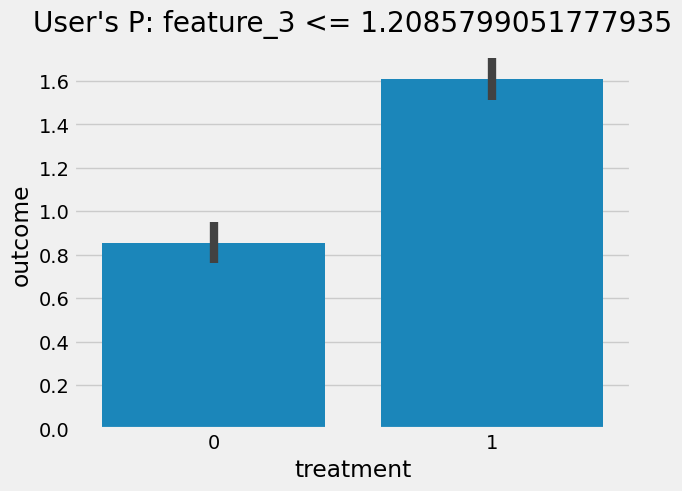

In [2]:
# visualize the user's query data.q_df where T0=1 and T1=0

# create a barplot grouping T for data.q_df
sns.barplot(x='treatment', y='outcome', data=data.q_df)
plt.title("User's P: "+ data.p)

In [3]:
iteration = 0

# Recommendations from CT on D

In [4]:
top = scores[(scores['iteration']==iteration) & (scores['algorithm']=='CT on D')].sort_values('score', ascending=False)
top

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,true_score,algorithm,iteration,features,p,execution_time
0,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,2.654,4.956,0.01,-0.037235,4.918357,6,1.000000,0.604000,0.604000,CT on D,0,4.0,feature_2 > -0.9129810751169849,NaN
1,feature_2 > -1.159,0.796,0.873,0.94,0.977846,1.850938,1,0.176150,0.481690,0.555955,CT on D,0,1.0,feature_2 > -0.9129810751169849,NaN
2,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,2.654,3.845,0.04,0.876537,4.721840,5,0.775827,0.481496,0.616000,CT on D,0,4.0,feature_2 > -0.9129810751169849,NaN
3,feature_2 <= -1.159 AND feature_0 > 0.499 AND ...,2.623,3.664,0.00,0.990952,4.654804,3,0.739306,0.443584,0.592992,CT on D,0,3.0,feature_2 > -0.9129810751169849,NaN
4,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,2.304,3.521,0.01,1.039620,4.561081,5,0.710452,0.430271,0.524874,CT on D,0,4.0,feature_2 > -0.9129810751169849,NaN


In [5]:
def visualize_recommendations(scores, k=5):
    scores = scores.sort_values('score', ascending=False)
    # for K in range(k):
    #     topK = top.iloc[K]

    #     topK['condition'] = topK['condition'].replace('AND', '\n AND')

    #     sns.barplot(x=['T0', 'T1'], y=[topK['T0'], topK['T1']])
    #     plt.title('Estimations from '+ topK['algorithm'] +', K='+str(K+1))
    #     plt.xlabel("treatment")
    #     plt.ylabel("outcome")
    #     # add a plot label with the condition top1['condition'] with extra small font
    #     plt.text(-1, -2, topK['condition'] +'\n\n Score: 0.6*'+str(topK['t_est']) + " + (1-0.6)*" +str(topK['distance']) + " = " + str(round(topK['score'],2)), fontsize=11)
    #     plt.show()


    fig, axs = plt.subplots(k, 1, figsize=(10,20), tight_layout = True)
    fig.suptitle('Estimations from '+ scores.iloc[0]['algorithm'])
    for i in range(k):
        topK = scores.iloc[i]
        topK['condition'] = topK['condition'].replace('AND', '\n AND')
        
        sns.barplot(x=['T0', 'T1'], y=[topK['T0'], topK['T1']], ax=axs[i])
        axs[i].set_title('K='+str(i+1))
        axs[i].set_xlabel("treatment")
        axs[i].set_ylabel("outcome")

        outer_text = f"{topK['condition']} \n\n Score: 0.6*{str(topK['t_est'])} + (1-0.6)*{str(topK['distance'])}  =  {str(round(topK['score'],2))}"
        axs[i].annotate(outer_text, xy=(1, 1), xycoords='axes fraction', xytext=(1.02, 1), textcoords='axes fraction', ha='left', va='top')

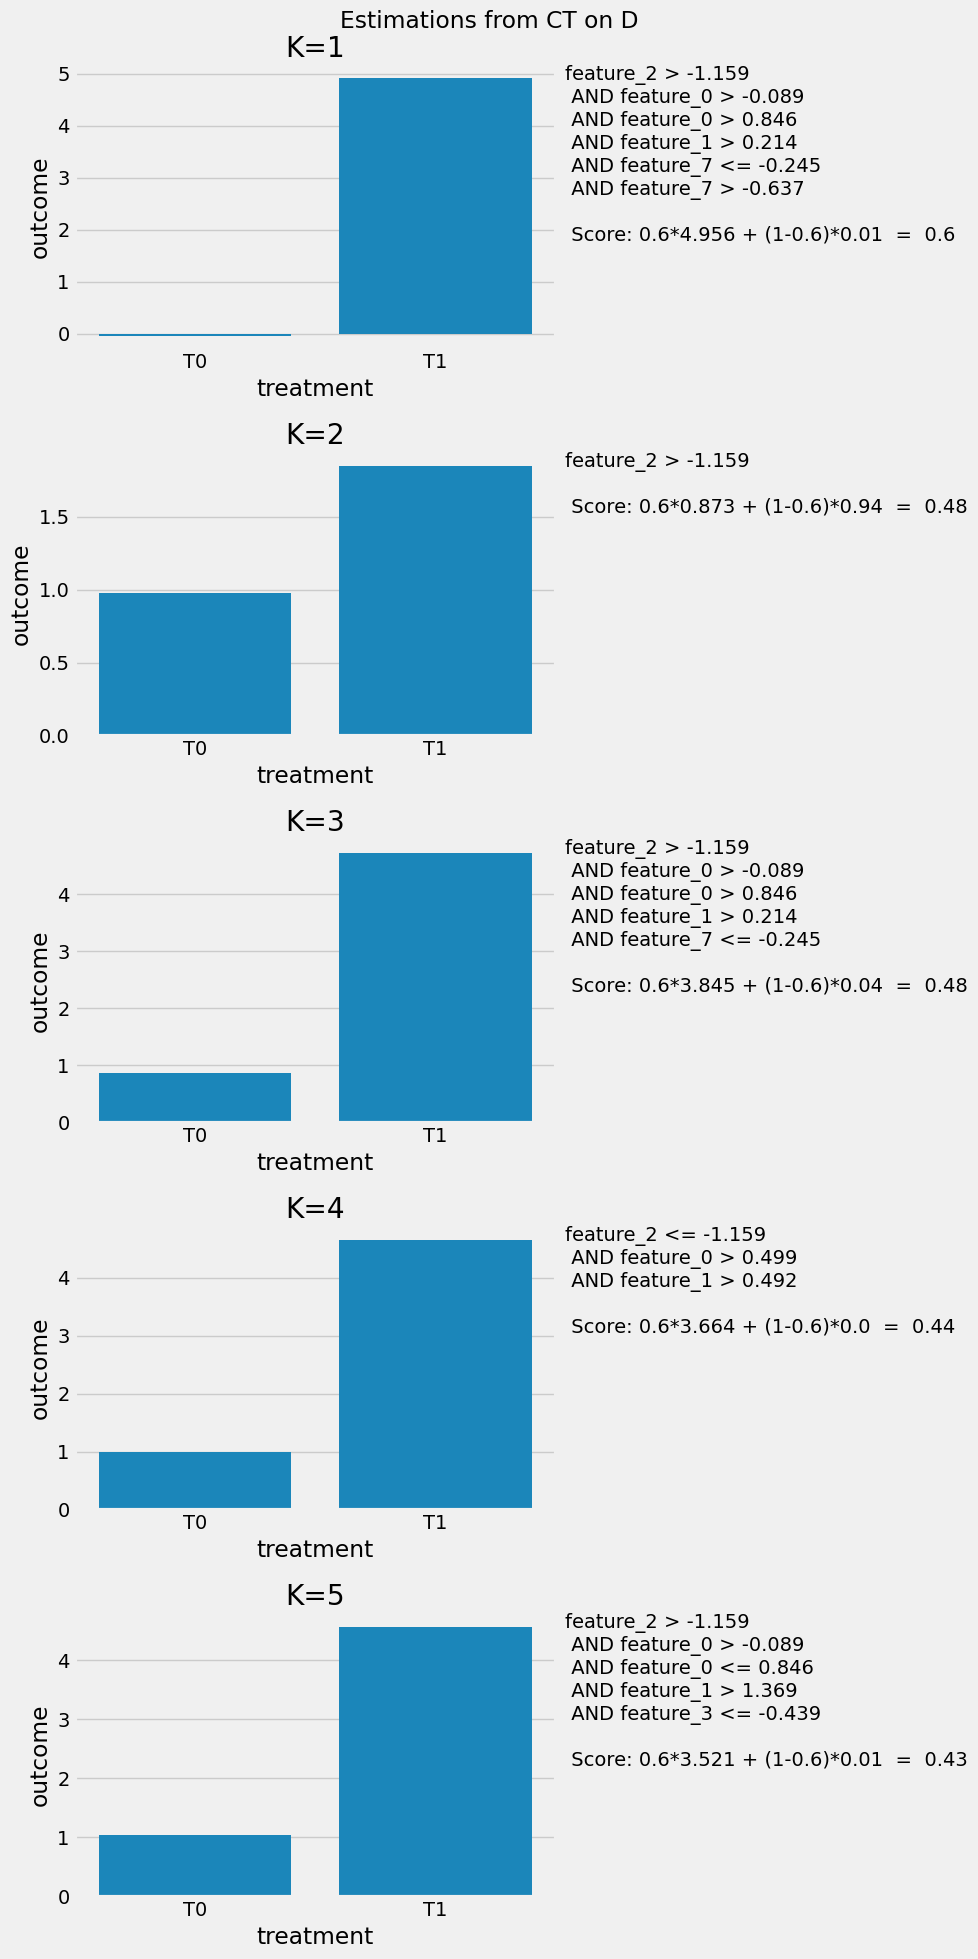

In [6]:
visualize_recommendations(top)

# Recommendations from CT on P

In [7]:
top = scores[(scores['iteration']==iteration) & (scores['algorithm']=='CT on P')].sort_values('score', ascending=False)
top

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,true_score,algorithm,iteration,features,p,execution_time
5,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.885,3.913,0.02,1.074259,4.986802,6,1.000000,0.608000,0.536550,CT on P,0,3.0,feature_2 > -0.9129810751169849,NaN
6,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.583,3.481,0.04,0.773198,4.254470,5,0.889599,0.549759,0.489221,CT on P,0,3.0,feature_2 > -0.9129810751169849,NaN
7,feature_0 <= 2.171,0.762,0.857,0.99,0.990782,1.847382,1,0.219014,0.527408,0.535603,CT on P,0,1.0,feature_2 > -0.9129810751169849,NaN
8,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.574,2.992,0.06,1.019410,4.011811,4,0.764631,0.482778,0.495573,CT on P,0,2.0,feature_2 > -0.9129810751169849,NaN
9,feature_0 > 2.171,3.275,3.049,0.01,1.629222,4.677820,1,0.779198,0.471519,0.604000,CT on P,0,1.0,feature_2 > -0.9129810751169849,NaN


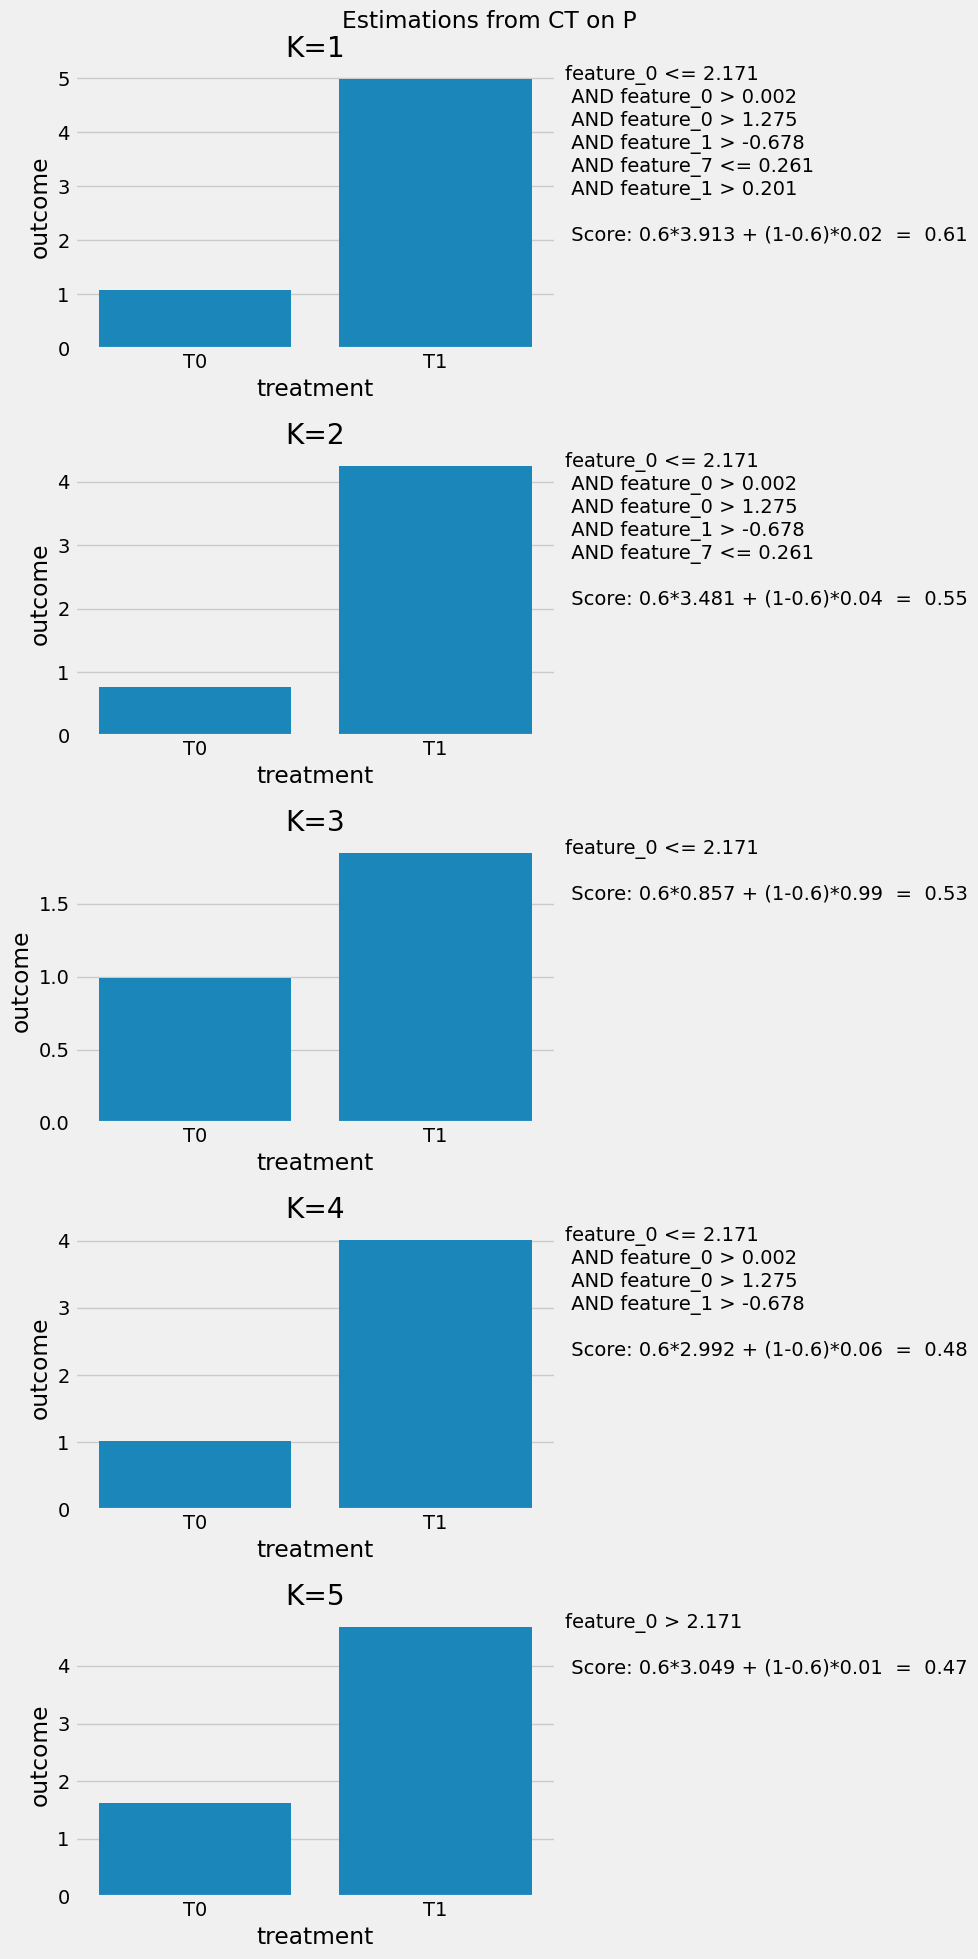

In [8]:
visualize_recommendations(top)

In [9]:
top = scores[(scores['iteration']==iteration) & (scores['algorithm']=='CT on P')].sort_values('score', ascending=False)
top

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,true_score,algorithm,iteration,features,p,execution_time
5,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.885,3.913,0.02,1.074259,4.986802,6,1.000000,0.608000,0.536550,CT on P,0,3.0,feature_2 > -0.9129810751169849,NaN
6,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.583,3.481,0.04,0.773198,4.254470,5,0.889599,0.549759,0.489221,CT on P,0,3.0,feature_2 > -0.9129810751169849,NaN
7,feature_0 <= 2.171,0.762,0.857,0.99,0.990782,1.847382,1,0.219014,0.527408,0.535603,CT on P,0,1.0,feature_2 > -0.9129810751169849,NaN
8,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.574,2.992,0.06,1.019410,4.011811,4,0.764631,0.482778,0.495573,CT on P,0,2.0,feature_2 > -0.9129810751169849,NaN
9,feature_0 > 2.171,3.275,3.049,0.01,1.629222,4.677820,1,0.779198,0.471519,0.604000,CT on P,0,1.0,feature_2 > -0.9129810751169849,NaN


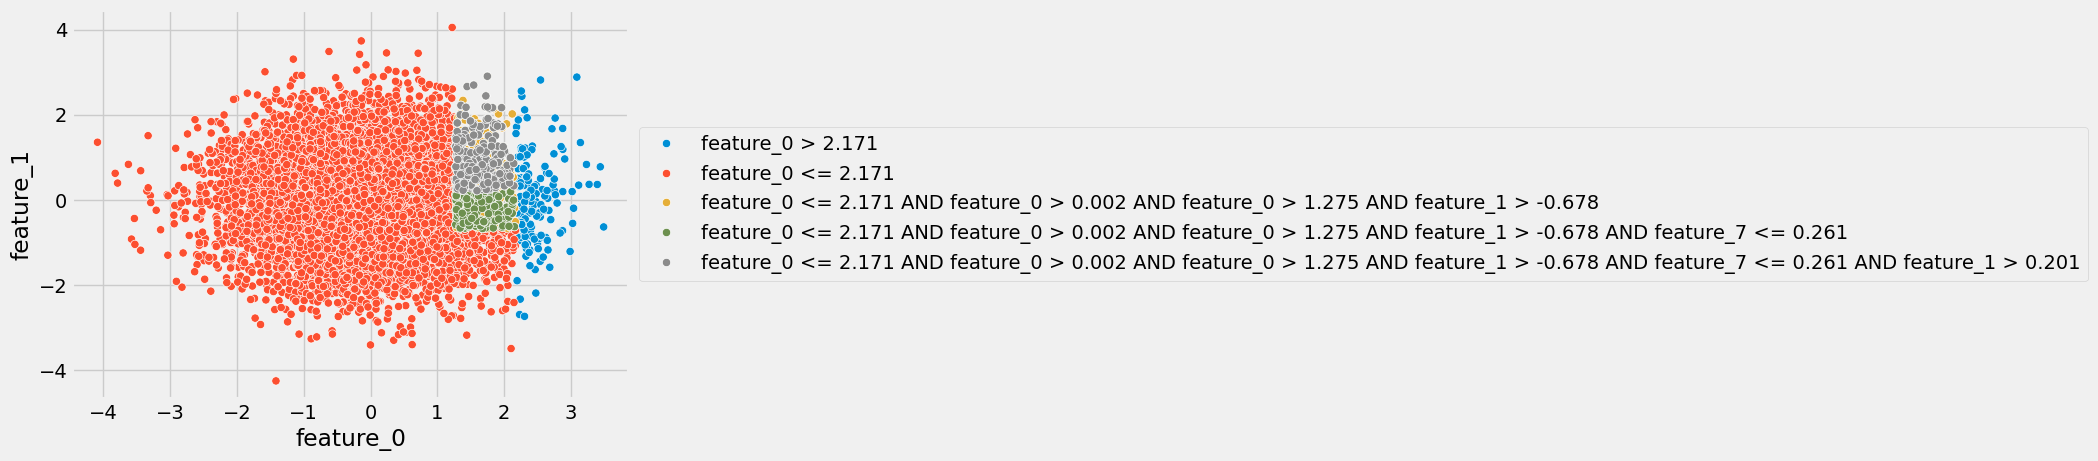

In [10]:
# create a single plot with the 5 classes based on each recommendation
import polars as pl

df_plot = pd.DataFrame(columns=['feature_0', 'feature_1', 'condition'])
for i in [4,2, 3,1,0]:
    condition = top.iloc[i]['condition']
    dt = data.execute(condition)
    dt = dt[['feature_0', 'feature_1']]

    dt = pd.DataFrame(dt, columns=['feature_0', 'feature_1'])
    dt['condition'] = condition

    df_plot = pd.concat([df_plot, dt], ignore_index=True)
    
sns.scatterplot(x='feature_0', y='feature_1', hue='condition', data=df_plot)
# reduce legend size
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)